In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Set display options for better readability
pd.options.display.float_format = '{:.2f}'.format

# Load data
df = pd.read_csv('out.csv')

# Exclude 'AV' invoices
df = df[df['NATURE'] != 'AV'].copy()

# Convert 'Date' to datetime and extract temporal features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Create cyclical features for Month
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Create lag features with median imputation
df = df.sort_values('Date')
df['lag_1'] = df['Net_TTC'].shift(1).fillna(df['Net_TTC'].median())
df['lag_2'] = df['Net_TTC'].shift(2).fillna(df['Net_TTC'].median())

# Apply log transformation to handle skewed financial data
df['log_Net_TTC'] = np.log1p(df['Net_TTC'])
df['log_Brut'] = np.log1p(df['Brut'])
df['log_Cout_de_revient'] = np.log1p(df['Cout_de_revient'])

# Define features and target
features = ['year', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'Categories_produits', 'log_Brut', 'log_Cout_de_revient']
target = 'log_Net_TTC'

# Define preprocessing pipeline
numeric_features = ['log_Brut', 'log_Cout_de_revient', 'lag_1', 'lag_2', 'month_sin', 'month_cos']
categorical_features = ['Categories_produits', 'year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Prepare training data (2023 and 2024)
train_df = df[df['year'].isin([2023, 2024])]
X_train = train_df[features]
y_train = train_df[target]

# Define models with hyperparameter grids
models = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'param_grid': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [10, 20, None],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'param_grid': {
            'regressor__n_neighbors': [3, 5, 7],
            'regressor__weights': ['uniform', 'distance']
        }
    },
    'SVR': {
        'model': SVR(),
        'param_grid': {
            'regressor__C': [0.1, 1, 10],
            'regressor__epsilon': [0.1, 0.5]
        }
    }
}

# Evaluate and optimize models
print("\nComparaison des modèles optimisés :")
results = []
best_models = {}
for name, config in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', config['model'])])
    grid_search = GridSearchCV(
        pipeline,
        config['param_grid'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    # Evaluate with MSE, RMSE, and R²
    mse = -grid_search.best_score_
    rmse = np.sqrt(mse)
    r2_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
    r2 = r2_scores.mean()

    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R²': r2})
    print(f"{name} - MSE: {mse}, RMSE: {rmse}, R²: {r2}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nRésultats des modèles :")
print(results_df[['Model', 'MSE', 'RMSE', 'R²']])

# Select and train the best model
best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_model = best_models[best_model_name]
print(f"\nMeilleur modèle : {best_model_name}")
best_model.fit(X_train, y_train)

# Predict for 2025
df_2025 = df[df['year'] == 2025][features]
predictions_2025_log = best_model.predict(df_2025)
predictions_2025 = np.expm1(predictions_2025_log)

# Aggregate predictions for 2025
total_net_ttc_2025_partial = predictions_2025.sum()
num_factures_2025_partial = len(df_2025)

# Extrapolate to full year (Jan-Feb ≈ 2 months, factor = 12/2 = 6)
extrapolation_factor = 12 / 2
total_net_ttc_2025 = total_net_ttc_2025_partial * extrapolation_factor
num_factures_2025 = num_factures_2025_partial * extrapolation_factor

# Aggregate data for 2023 and 2024
agg_data = df[df['year'].isin([2023, 2024])].groupby('year').agg({
    'Net_TTC': 'sum',
}).reset_index()

# Add 2025 predictions
agg_data_2025 = pd.DataFrame({
    'year': [2025],
    'Net_TTC': [total_net_ttc_2025]
})

# Combine financial results
agg_data = pd.concat([agg_data, agg_data_2025], ignore_index=True)
print("\nComparaison des résultats financiers par année :")
print(agg_data)

# Save results
results_df.to_csv('model_comparison.csv', index=False)
agg_data.to_csv('financial_results.csv', index=False)
print("\nRésultats enregistrés dans 'model_comparison.csv' et 'financial_results.csv'")





Comparaison des modèles optimisés :
Random Forest - MSE: 0.0009506159152483966, RMSE: 0.030832059860612566, R²: 0.9995351790505385
KNN - MSE: 0.11117673644018067, RMSE: 0.3334317567961706, R²: 0.9449737094584801
SVR - MSE: 0.020661679925460256, RMSE: 0.143741712545316, R²: 0.9898271618225973

Résultats des modèles :
           Model  MSE  RMSE   R²
0  Random Forest 0.00  0.03 1.00
1            KNN 0.11  0.33 0.94
2            SVR 0.02  0.14 0.99

Meilleur modèle : Random Forest

Comparaison des résultats financiers par année :
   year    Net_TTC
0  2023 6666739.06
1  2024 7455338.97
2  2025 7877355.11

Résultats enregistrés dans 'model_comparison.csv' et 'financial_results.csv'


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


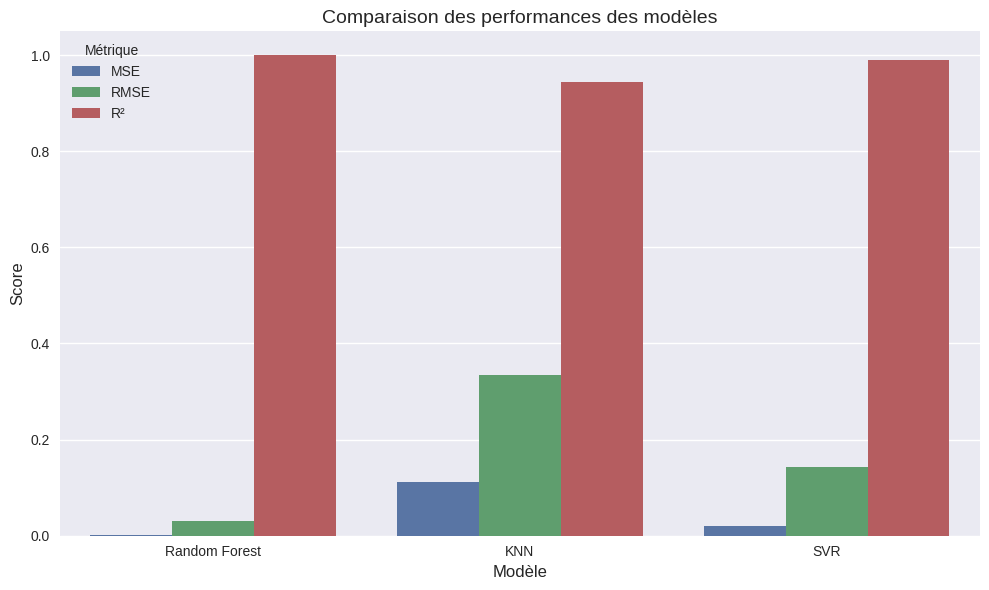

<ipython-input-3-7e843a2e8dcd>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_data, x='year', y='Net_TTC', palette='viridis')


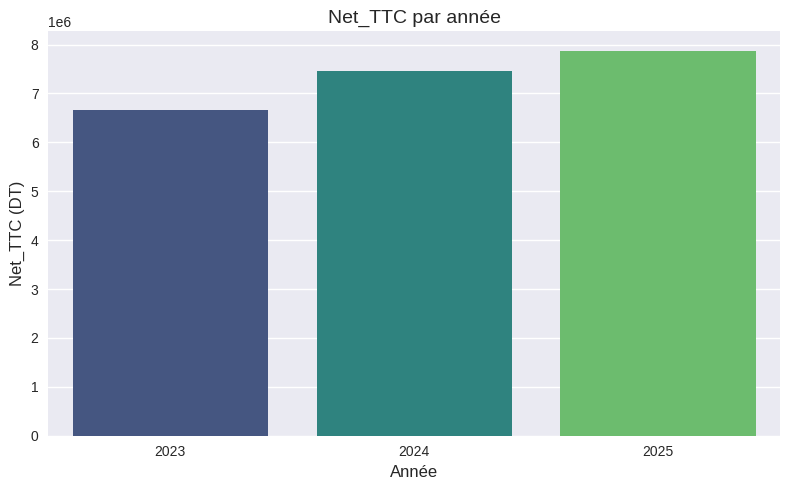

In [3]:
# Visualizations
# plt.style.use('seaborn') # Deprecated/Removed style
plt.style.use('seaborn-v0_8') # Use a currently supported seaborn style

# 1. Model performance comparison
metrics_melted = results_df.melt(id_vars='Model', value_vars=['MSE', 'RMSE', 'R²'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Model', y='Score', hue='Metric')
plt.title('Comparaison des performances des modèles', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Modèle', fontsize=12)
plt.legend(title='Métrique')
plt.tight_layout()
plt.savefig('model_comparison_plot.png')
plt.show()

# Visualisation de Net_TTC par année
plt.figure(figsize=(8, 5))
sns.barplot(data=agg_data, x='year', y='Net_TTC', palette='viridis')
plt.title('Net_TTC par année', fontsize=14)
plt.ylabel('Net_TTC (DT)', fontsize=12)
plt.xlabel('Année', fontsize=12)
plt.tight_layout()
plt.savefig('net_ttc_par_annee.png')
plt.show()
